In [7]:
# Goal: Import and preprocess one parquet subset of the lichess data available at
# huggingface.co/datasets/thomasd1/aix-lichess-database

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

duckdb.sql("SELECT 42").show() # test
duckdb.sql("LOAD aixchess")

┌───────┐
│  42   │
│ int32 │
├───────┤
│    42 │
└───────┘



In [ ]:
# store the dataset lazily in memory
from pathlib import Path

chunk_path = Path("games.parquet")
if not chunk_path.exists():
    lichess_2025_01 = duckdb.read_parquet(
        'hf://datasets/thomasd1/aix-lichess-database/high_compression/aix_lichess_2025-01_high.parquet'
    )
    duckdb.sql(f"""COPY lichess_2025_01 TO '{chunk_path}'""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
games = duckdb.sql("FROM games.parquet")
# count games to get a sense of scale
duckdb.sql("SELECT COUNT(*) FROM games")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│    100412379 │
└──────────────┘

In [9]:
# get an idea of what the data looks like, slice first 50
df = duckdb.sql("SELECT * FROM games LIMIT 50").df()
df

,lichess_id,tournament,movedata,clocks_white,clocks_black,evals,ply_count,white,black,white_rating,...,time_increment,result,termination,white_rating_diff,black_rating_diff,eco,opening,white_title,black_title,utc_timestamp
0,eh5dKZuD,None,"[241, 18, 239, 174, 156, 134, 227, 1, 229, 48,...","[180, 179, 177, 176, 175, 171, 165, 162, 158, ...","[180, 179, 178, 175, 173, 163, 154, 144, 140, ...",<NA>,29,Panchito0O,PauloPeru78,1247,...,0,1-0,Normal,5,-5,C25,Vienna Game: Anderssen Defense,NaN,None,2025-01-01 00:00:05
1,6yXyLl2M,None,"[101, 159, 227, 191, 169, 220, 62, 140, 234, 9...","[180, 179, 178, 177, 174, 173, 172, 171, 169, ...","[180, 180, 179, 178, 178, 177, 176, 176, 174, ...",<NA>,104,igloknight,atacan3131,1577,...,0,0-1,Time forfeit,-6,6,B12,Caro-Kann Defense: Masi Variation,NaN,None,2025-01-01 00:00:05
2,SZW2amZz,None,"[45, 180, 75, 178, 67, 223, 163, 87, 101, 109,...","[180, 179, 179, 177, 175, 173, 172, 171, 169, ...","[180, 178, 175, 174, 173, 171, 169, 168, 163, ...",<NA>,87,draughts2chess,xhoxhi64,1043,...,0,1-0,Normal,10,-5,D00,Queen's Pawn Game,NaN,None,2025-01-01 00:00:05
3,VGhr7swl,None,"[179, 115, 175, 102, 11, 140, 124, 148, 247, 2...","[180, 176, 174, 172, 168, 167, 165, 158, 142, ...","[180, 180, 180, 179, 177, 176, 176, 166, 158, ...",<NA>,58,GodofPastries,Mickey187,2015,...,0,1-0,Normal,6,-11,B13,Caro-Kann Defense: Exchange Variation,NaN,None,2025-01-01 00:00:05
4,aQTAJkjw,None,"[179, 201, 247, 191, 244, 17, 222, 158, 133, 4...","[180, 179, 179, 177, 177, 177, 176, 176, 176, ...","[180, 178, 177, 177, 177, 175, 173, 172, 171, ...",<NA>,112,elprimo27,knocikIII,2139,...,0,0-1,Normal,-6,5,B10,Caro-Kann Defense: Endgame Variation,NaN,None,2025-01-01 00:00:05
5,q3nLXkE4,None,"[83, 46, 207, 195, 97, 250, 93, 127, 225, 88, ...","[180, 178, 177, 176, 172, 169, 168, 162, 162, ...","[180, 180, 179, 179, 179, 178, 177, 175, 173, ...",<NA>,42,gustavstromberg,kaddy3,1756,...,0,1-0,Normal,5,-5,B06,Modern Defense: Two Knights Variation,NaN,None,2025-01-01 00:00:05
6,HFLSck3z,None,"[101, 36, 37, 83, 59, 168, 243, 180, 244, 148,...","[180, 177, 171, 169, 167, 166, 165, 164, 163, ...","[180, 180, 180, 179, 179, 177, 176, 175, 175, ...",<NA>,89,rennbj4,XXXZeusXXX,1638,...,0,1-0,Time forfeit,6,-7,A40,Queen's Pawn Game,NaN,None,2025-01-01 00:00:05
7,Iyv5e6Y1,None,"[199, 189, 146, 247, 172, 74, 48, 22, 12, 133,...","[180, 180, 172, 171, 171, 170, 170, 168, 165, ...","[180, 179, 176, 174, 172, 170, 168, 166, 161, ...",<NA>,89,diegocrafter44,espenono,1841,...,0,1-0,Normal,6,-5,C00,French Defense: Normal Variation,NaN,None,2025-01-01 00:00:05
8,ULFsvszI,None,"[143, 184, 122, 182, 29, 101, 165, 244, 194, 3...","[180, 175, 172, 171, 166, 164, 161, 157, 153, ...","[180, 178, 177, 175, 173, 169, 167, 163, 155, ...",<NA>,58,Not-Magnus-C,Yala_Baba,1699,...,0,0-1,Normal,-5,6,C35,King's Gambit Accepted: Cunningham Defense,NaN,None,2025-01-01 00:00:05
9,ba6M0iTF,None,"[31, 69, 204, 129, 17, 168, 76, 34, 184, 126, ...","[180, 179, 177, 176, 175, 173, 171, 170, 169, ...","[180, 180, 180, 180, 178, 175, 174, 173, 173, ...",<NA>,47,Nosferatu_rrr,Perinell,1496,...,0,1-0,Normal,7,-6,C20,King's Pawn Game: Leonardis Variation,NaN,None,2025-01-01 00:00:05


array([[<Axes: title={'center': 'white_rating'}>]], dtype=object)

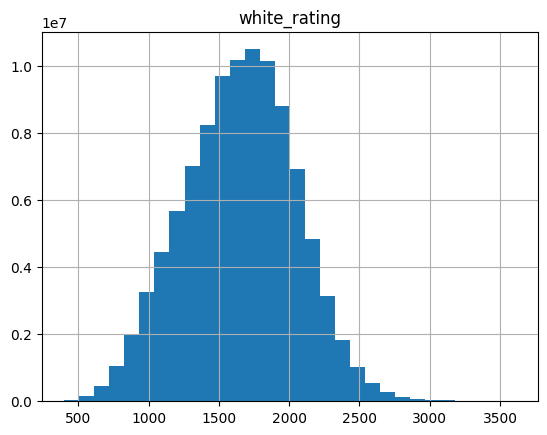

In [10]:
# rating histogram
duckdb.sql("SELECT white_rating FROM games").df().hist(bins=30)

In [11]:
result_df = duckdb.sql("""
SELECT result, count(result) 
FROM games
GROUP BY result
""").df()
result_df

,result,count(result)
0,0-1,46484411
1,*,185273
2,1/2-1/2,3935904
3,1-0,49806791


In [12]:
# Looks like there's some incomplete games (*). 
# We should filter these out, because we should never predict an incomplete game -- they happen due to external situations such as bugs.

# Let's split off the first 100k rows and create a very quick and dirty baseline. 
# This is a good number because you can fit 100k rows in a single dataframe.

subset = duckdb.sql("FROM games WHERE result != '*' LIMIT 100000")

duckdb.sql("COPY subset TO subset.parquet")

# To be continued

See `02_baseline.ipynb` for a simple logistic regression baseline using only elo.